In [81]:
import numpy as np
import pandas as pd

from pathlib import Path

from scipy.ndimage import gaussian_filter1d
from utils.config import Params
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Rectangle
from matplotlib.path import Path as mPath

import ipywidgets as widgets
from IPython.display import display, clear_output

from scipy import stats
from scipy.interpolate import interp1d
from scipy.signal import hilbert

from utils import load_pickle,extract_used_data,mergeAB,set_params

In [82]:
def calc_fft_hilbert_envelope(
    fr,
    axis=-1,
    max_cycle=8,
    smooth_sigma=0,
    pad_bins=None,
):
    """
    r -> optional smooth -> FFT remove DC and high cycles -> f -> Hilbert envelope

    Parameters
    ----------
    fr : ndarray
        Usually n_neuron × n_trial × T.
    axis : int
        Position axis.
    max_cycle : int
        Keep Fourier components from 1 to max_cycle per track.
        k=0 is removed.
    smooth_sigma : float
        Optional Gaussian smoothing before FFT, in bins.
        If 0, no smoothing.
    pad_bins : int or None
        Reflection padding length. If None, use T//2.

    Returns
    -------
    envelope : ndarray
        Same shape as fr.
    f : ndarray
        Filtered oscillatory component.
    """

    fr = np.asarray(fr, dtype=float)

    if smooth_sigma is not None and smooth_sigma > 0:
        r = gaussian_filter1d(
            fr,
            sigma=smooth_sigma,
            axis=axis,
            mode="reflect",
            truncate=3.0,
        )
    else:
        r = fr.copy()

    # move position axis to last
    x = np.moveaxis(r, axis, -1)
    T = x.shape[-1]

    if pad_bins is None:
        pad_bins = T // 2

    # mirror padding: reduce FFT/Hilbert boundary artifact
    x_pad = np.pad(
        x,
        pad_width=[(0, 0)] * (x.ndim - 1) + [(pad_bins, pad_bins)],
        mode="reflect",
    )

    Tp = x_pad.shape[-1]

    # FFT
    X = np.fft.rfft(x_pad, axis=-1)

    # frequency index k means k cycles over padded signal
    keep = np.zeros(X.shape[-1], dtype=bool)

    # remove DC: keep[0] = False
    kmax = min(max_cycle, X.shape[-1] - 1)
    keep[1:kmax + 1] = True

    shape = [1] * X.ndim
    shape[-1] = keep.size
    keep = keep.reshape(shape)

    X_filt = X * keep

    # filtered oscillatory component f
    f_pad = np.fft.irfft(X_filt, n=Tp, axis=-1)

    # Hilbert envelope
    analytic = hilbert(f_pad, axis=-1)
    env_pad = np.abs(analytic)

    # crop back
    f = f_pad[..., pad_bins:pad_bins + T]
    envelope = env_pad[..., pad_bins:pad_bins + T]

    # move axis back
    f = np.moveaxis(f, -1, axis)
    envelope = np.moveaxis(envelope, -1, axis)

    return envelope, f

In [83]:
def align_track(
    data: dict,
    params,
    max_cycle=15,
    envelope_smooth_sigma=0,
    envelope_pad_bins=None,
):
    aligned_firing = np.empty_like(data["simple_firing"], dtype=object)
    aligned_firing_std = np.empty_like(data["simple_firing"], dtype=object)

    aligned_envelope = np.empty_like(data["simple_firing"], dtype=object)
    aligned_envelope_std = np.empty_like(data["simple_firing"], dtype=object)

    aligned_f = np.empty_like(data["simple_firing"], dtype=object)

    for index in params.total_index_grid:

        fr = data["simple_firing"][index]
        if fr is None:
            continue

        fr = np.asarray(fr, dtype=float)

        if fr.ndim != 3:
            raise ValueError(f"fr should be n_neuron × n_trial × T, got {fr.shape}")

        # original firing for ACG / firing plot
        if params.gaussian_sigma > 0:
            fr_smooth = gaussian_filter1d(
                fr,
                sigma=params.gaussian_sigma,
                axis=2,
                mode="reflect",
                truncate=3.0,
            )
        else:
            fr_smooth = fr.copy()

        aligned_firing[index] = np.nanmean(fr_smooth, axis=1)
        aligned_firing_std[index] = (
            np.nanstd(fr_smooth, axis=1) / np.sqrt(fr_smooth.shape[1])
        )

        # FFT filtered f and Hilbert envelope
        env, f = calc_fft_hilbert_envelope(
            fr,
            axis=2,
            max_cycle=max_cycle,
            smooth_sigma=envelope_smooth_sigma,
            pad_bins=envelope_pad_bins,
        )

        aligned_envelope[index] = np.nanmean(env, axis=1)
        aligned_envelope_std[index] = (
            np.nanstd(env, axis=1) / np.sqrt(env.shape[1])
        )

        aligned_f[index] = np.nanmean(f, axis=1)

    aligned_zones_id = np.empty_like(data["zones"], dtype=int)

    for i, zone in enumerate(data["zones"]):
        start = int(zone[0] / params.space_unit) - 1
        end = int(zone[1] / params.space_unit) + 1

        start = max(start, 0)
        end = min(end, params.len_track)

        aligned_zones_id[i] = [start, end]

    data["aligned_firing"] = aligned_firing
    data["aligned_firing_std"] = aligned_firing_std

    data["aligned_envelope"] = aligned_envelope
    data["aligned_envelope_std"] = aligned_envelope_std
    data["aligned_f"] = aligned_f

    data["aligned_zones_id"] = aligned_zones_id

In [84]:
def calc_if_firing_legal(data: dict, params: Params, ana_tt: list, ana_bt: list, min_firing=3):
    is_legal_list = []
    for index in params.ana_index_grid(ana_tt, ana_bt):
        fr = data["aligned_firing"][index]
        if fr is None:
            continue
        # (n_neuron, T) -> (n_neuron,)
        is_legal = (np.nanmax(fr, axis=1) > min_firing).astype(np.int8)
        is_legal_list.append(is_legal)
    if len(is_legal_list) == 0:
        return None
    return np.all(np.stack(is_legal_list, axis=0), axis=0)


def calc_if_3Hz_oscillation(
    data: dict,
    params: Params,
    ana_tt: list,
    ana_bt: list,
    dist: int,
    min_overlap: int = 3,
):
    is_3hz_list = []
    ok_list = []

    if "firing_acg" not in data:
        data["firing_acg"] = np.empty_like(data["aligned_firing"], dtype=object)
    if "acg_fft" not in data:
        data["acg_fft"] = np.empty_like(data["aligned_firing"], dtype=object)


    for index in params.ana_index_grid(ana_tt, ana_bt):
        fr = data["aligned_firing"][index]
        if fr is None:
            continue

        fr = np.asarray(fr, dtype=float)  # (n_neuron, T)
        if np.isnan(fr).any():
            raise ValueError("Firing rates contain NaN values.")
        
        n_neuron, T = fr.shape
        max_lag = min(dist, T - 1)
        L = 2 * max_lag + 1  # ACG clip length

        rfft_len = (L // 2) + 1
        if rfft_len < 6 or (T < min_overlap):
            raise ValueError("ACG length too short to compute 3Hz component.")

        acg = np.full((n_neuron, L), np.nan, dtype=float)
        center = max_lag
        for k in range(0, max_lag + 1):
            overlap = T - k  # 一定 >= min_overlap

            a = fr[:, :overlap]
            b = fr[:, k:k + overlap]

            ma = np.mean(a, axis=1, keepdims=True)
            mb = np.mean(b, axis=1, keepdims=True)

            da = a - ma
            db = b - mb

            sa = np.sqrt(np.mean(da * da, axis=1))
            sb = np.sqrt(np.mean(db * db, axis=1))

            denom = sa * sb
            num = np.mean(da * db, axis=1)

            c = np.full(n_neuron, np.nan, dtype=float)
            ok_corr = np.isfinite(denom) & (denom > 1e-10) & np.isfinite(num)
            c[ok_corr] = num[ok_corr] / denom[ok_corr]

            acg[:, center + k] = c
            acg[:, center - k] = c

        invalid = np.isnan(acg).any(axis=1)

        P_full = np.full((n_neuron, rfft_len), np.nan, dtype=float)

        ok = ~invalid
        is_3hz = np.zeros(n_neuron, dtype=np.int8)

        if np.any(ok):
            acg_ok = acg[ok]
            
            L = acg_ok.shape[1]
            
            # acg0 = acg_ok - acg_ok.mean(axis=1, keepdims=True)

            X = np.fft.rfft(acg_ok, axis=1)
            P = (np.abs(X)**2) / L
            P[:, 0] = 0  # Zero out DC component

            cond = (P[:, 4] > P[:, 3]) & (P[:, 4] > P[:, 5])
            is_3hz[ok] = cond.astype(np.int8)
            P_full[ok] = P

        data["firing_acg"][index] = acg
        data["acg_fft"][index] = P_full
        is_3hz_list.append(is_3hz)
        ok_list.append(ok)

    if len(is_3hz_list) == 0:
        raise ValueError("No valid data found for the specified trial types and behaviors.")

    return np.all(np.stack(is_3hz_list, axis=0), axis=0), np.all(np.stack(ok_list, axis=0), axis=0)



In [85]:
def compute_one_rule_3hz_mask(
    data,
    params,
    rule,
    dist,
    min_firing=3,
    ana_bt=("correct",),
    verbose=True,
):
    """
    Compute final 3Hz mask for one rule.

    final mask:
        is_3hz & legal_firing & valid
    """
    ana_tt = [f"{rule}*"]
    ana_bt = list(ana_bt)

    is_legal = calc_if_firing_legal(
        data,
        params,
        ana_tt=ana_tt,
        ana_bt=ana_bt,
        min_firing=min_firing,
    )

    is_3hz, valid = calc_if_3Hz_oscillation(
        data,
        params,
        ana_tt=ana_tt,
        ana_bt=ana_bt,
        dist=dist,
    )

    mask = is_3hz & is_legal & valid

    n_total = len(mask)
    n_legal = int(np.sum(is_legal))
    n_3hz = int(np.sum(mask))

    if verbose:
        print(f"rule: {rule}")
        print(f"minimum firing: {min_firing}")
        print(f"legal num: {n_legal}")
        print(f"total num: {n_total}")
        print(f"legal ratio: {n_legal / max(n_total, 1):.4f}")
        print(f"3Hz num: {n_3hz}")
        print(f"3Hz ratio among legal: {n_3hz / max(n_legal, 1):.4f}")

    return mask, {
        "rule": rule,
        "n_total": n_total,
        "n_legal": n_legal,
        "n_3hz": n_3hz,
        "legal_ratio": n_legal / max(n_total, 1),
        "ratio_3hz_among_legal": n_3hz / max(n_legal, 1),
    }
    
    
def compute_two_rule_3hz_mask(
    data,
    params,
    rule1,
    rule2,
    dist,
    min_firing=3,
    ana_bt=("correct",),
    verbose=True,
):
    """
    Compute shared 3Hz mask for paired comparison between two rules.

    A neuron is included if:
        1. it is valid in both rules
        2. it is 3Hz in at least one rule
        3. it passes legal firing criterion in the corresponding rule

    This matches the original run_on logic.
    """
    ana_bt = list(ana_bt)

    is_legal1 = calc_if_firing_legal(
        data,
        params,
        ana_tt=[f"{rule1}*"],
        ana_bt=ana_bt,
        min_firing=min_firing,
    )

    is_legal2 = calc_if_firing_legal(
        data,
        params,
        ana_tt=[f"{rule2}*"],
        ana_bt=ana_bt,
        min_firing=min_firing,
    )

    is_legal = is_legal1 | is_legal2

    is_3hz1, valid1 = calc_if_3Hz_oscillation(
        data,
        params,
        ana_tt=[f"{rule1}*"],
        ana_bt=ana_bt,
        dist=dist,
    )

    is_3hz2, valid2 = calc_if_3Hz_oscillation(
        data,
        params,
        ana_tt=[f"{rule2}*"],
        ana_bt=ana_bt,
        dist=dist,
    )

    mask = (
        ((is_3hz1 & is_legal1) | (is_3hz2 & is_legal2))
        & valid1
        & valid2
    )

    n_total = len(mask)
    n_legal = int(np.sum(is_legal))
    n_3hz = int(np.sum(mask))

    summary = {
        "rule1": rule1,
        "rule2": rule2,
        "n_total": n_total,
        "n_legal": n_legal,
        "n_3hz": n_3hz,
        "legal_ratio": n_legal / max(n_total, 1),
        "ratio_3hz_among_legal": n_3hz / max(n_legal, 1),
    }

    if verbose:
        print(f"rules: {rule1} vs {rule2}")
        print(f"minimum firing: {min_firing}")
        print(f"legal num: {n_legal}")
        print(f"total num: {n_total}")
        print(f"legal ratio: {summary['legal_ratio']:.4f}")
        print(f"3Hz num: {n_3hz}")
        print(f"3Hz ratio among legal: {summary['ratio_3hz_among_legal']:.4f}")

    return mask, summary

In [86]:
def get_rule_envelope_peaks(
    data,
    params,
    rule,
    mask,
    ana_bt=("correct",),
):
    """
    Return peak positions of aligned_envelope for rule_1/rule_2/rule_3.

    Returns
    -------
    df_peak : DataFrame
        Columns: neuron_id, rule_1, rule_2, rule_3
    peak_mat : ndarray
        Shape: n_selected_neuron × 3
    """

    mask = np.asarray(mask, dtype=bool)
    neuron_ids = np.where(mask)[0]

    peak_cols = []

    for sid in [1, 2, 3]:
        tt_name = f"{rule}_{sid}"

        indices = list(params.ana_index_grid(
            ana_tt=[tt_name],
            ana_bt=list(ana_bt),
        ))

        if len(indices) != 1:
            raise ValueError(f"{tt_name} matched {len(indices)} indices: {indices}")

        idx = indices[0]
        env = data["aligned_envelope"][idx]

        if env is None:
            raise ValueError(f"aligned_envelope is None for {tt_name}")

        env = np.asarray(env, dtype=float)
        env_sel = env[mask, :]

        peak_bin = np.nanargmax(env_sel, axis=1)
        peak_pos = peak_bin * params.space_unit * params.len_pos_average

        peak_cols.append(peak_pos)

        print(
            f"{tt_name}: idx={idx}, env={env.shape}, "
            f"selected={env_sel.shape}, "
            f"peak range={np.min(peak_pos):.1f}-{np.max(peak_pos):.1f}"
        )

    peak_mat = np.column_stack(peak_cols)

    df_peak = pd.DataFrame({
        "neuron_id": neuron_ids,
        f"{rule}_1": peak_mat[:, 0],
        f"{rule}_2": peak_mat[:, 1],
        f"{rule}_3": peak_mat[:, 2],
    })

    return df_peak, peak_mat

In [87]:
def p_to_stars(p):
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "n.s."


def plot_rule_peak_violin(
    peak_mat,
    rule,
    colors=("#4c72b0", "#c6923b", "#dd5f5f"),
):
    """
    Three-group violin plot.
    Only one overall Friedman test.
    """

    peak_mat = np.asarray(peak_mat, dtype=float)

    valid = np.isfinite(peak_mat).all(axis=1)
    peak_mat = peak_mat[valid]

    y1 = peak_mat[:, 0]
    y2 = peak_mat[:, 1]
    y3 = peak_mat[:, 2]

    stat, p = stats.friedmanchisquare(y1, y2, y3)
    stars = p_to_stars(p)

    fig, ax = plt.subplots(figsize=(5.2, 3.8))

    parts = ax.violinplot(
        [y1, y2, y3],
        positions=[1, 2, 3],
        widths=0.55,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )

    for body, c in zip(parts["bodies"], colors):
        body.set_facecolor(c)
        body.set_edgecolor("k")
        body.set_alpha(0.25)
        body.set_linewidth(1.2)

    rng = np.random.default_rng(0)

    for i, y in enumerate([y1, y2, y3], start=1):
        x = i + rng.normal(0, 0.055, size=len(y))

        ax.scatter(
            x,
            y,
            s=10,
            color=colors[i - 1],
            alpha=0.85,
            linewidths=0,
            zorder=3,
        )

        med = np.median(y)
        q1, q3 = np.percentile(y, [25, 75])

        ax.plot([i, i], [q1, q3], color="k", lw=2.2, zorder=4)
        ax.scatter([i], [med], s=35, color="k", zorder=5)

    y_min = np.min(peak_mat)
    y_max = np.max(peak_mat)
    yr = y_max - y_min if y_max > y_min else 1.0

    y_br = y_max + 0.08 * yr
    h = 0.03 * yr

    ax.plot(
        [1, 1, 3, 3],
        [y_br, y_br + h, y_br + h, y_br],
        color="k",
        lw=1.5,
        clip_on=False,
    )
    ax.text(
        2,
        y_br + h,
        stars,
        ha="center",
        va="bottom",
        fontsize=13,
    )

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(
        ["Cue at Pos. 1", "Cue at Pos. 2", "Cue at Pos. 3"],
        fontsize=12,
    )

    ax.set_ylabel("Peak Amplitude Position (cm)", fontsize=13)
    ax.set_title(f"{rule.capitalize()} Rule", fontsize=14)

    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(y_min - 0.05 * yr, y_br + 0.12 * yr)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()

    print(f"{rule}: Friedman p = {p:.4g}, n = {peak_mat.shape[0]}")

    return fig, ax, {
        "rule": rule,
        "test": "Friedman",
        "stat": stat,
        "p": p,
        "stars": stars,
        "n": peak_mat.shape[0],
    }

In [88]:
def load_merge_entry_dir(entry_dir, params):
    """
    Load all pkl files under entry_dir, preprocess, merge aligned firing data.

    Returns
    -------
    data : dict
        Merged data dictionary.
    """
    path = Path(entry_dir)

    data_list = []

    for file in sorted(path.glob("*.pkl")):
        data = load_pickle(file)
        data = extract_used_data(data)
        mergeAB(data)
        align_track(data, params)
        data_list.append(data)

    if len(data_list) == 0:
        raise ValueError(f"No valid pkl files found under {entry_dir}")

    merged = {}

    concat_keys = [
        "aligned_firing",
        "aligned_firing_std",
        "aligned_envelope",
        "aligned_envelope_std",
        
    ]

    copy_keys = [
        "zones",
        "aligned_zones_id",
    ]

    for key in concat_keys:
        if key not in data_list[0]:
            continue

        merged[key] = np.empty_like(data_list[0][key], dtype=object)

        for idx in np.ndindex(merged[key].shape):
            chunks = []

            for d in data_list:
                arr = d[key][idx]

                if arr is not None:
                    chunks.append(arr)

            if len(chunks) > 0:
                merged[key][idx] = np.concatenate(chunks, axis=0)

    for key in copy_keys:
        if key in data_list[0]:
            merged[key] = data_list[0][key]

    return merged

In [89]:
def plot_neuron_id_signal(
    data: dict,
    params,
    rule1: str,
    rule2: str,
    id: int,
    value_key="aligned_firing",
    std_key="aligned_firing_std",
    ylabel="Firing rate (Hz)",
    title_prefix="Example neuron",
    alpha=0.9,
    lw=1.5,
):
    """
    Plot one neuron's signal under two rule groups.

    Parameters
    ----------
    data : dict
        Data dictionary containing aligned signals.
    params : Params
        Parameter object.
    rule1, rule2 : str
        Rule names, e.g. "pattern" and "position",
        or "pattern_1", "position_1" depending on your ana_tt logic.
    id : int
        Neuron index.
    value_key : str
        Main signal key in data, e.g. "aligned_firing" or "aligned_envelope".
    std_key : str
        SEM/std signal key in data.
    ylabel : str
        Y-axis label.
    """

    color_map = {
        "pattern_1": "#1f77b4",
        "pattern_2": "#ff7f0e",
        "pattern_3": "#d62728",
        "position_1": "#1f77b4",
        "position_2": "#ff7f0e",
        "position_3": "#d62728",
    }

    zones_color = {
        0: "#1f77b4",
        2: "#ff7f0e",
        4: "#d62728",
    }

    zones = data.get("aligned_zones_id", [])

    def plot_one_rule(ax, rule: str):

        indices = params.ana_index_grid(
            ana_tt=[f"{rule}*"],
            ana_bt=["correct"],
        )

        for idx in indices:
            sig = data[value_key][idx]
            sig_std = data[std_key][idx]

            if sig is None:
                continue

            neuron_sig = sig[id, :]
            neuron_sig_std = sig_std[id, :]

            X = np.arange(neuron_sig.shape[0])
            tt = params.tt[idx[0]]

            c = color_map.get(tt, "#000000")

            ax.plot(
                X,
                neuron_sig,
                color=c,
                alpha=alpha,
                linewidth=lw,
            )

            ax.fill_between(
                X,
                neuron_sig - neuron_sig_std,
                neuron_sig + neuron_sig_std,
                color=c,
                alpha=0.2,
                linewidth=0,
            )

        h_frac = 0.05

        for zi, row in enumerate(zones):
            if zi not in zones_color:
                continue
            if len(row) < 2:
                continue

            start_x, end_x = float(row[0]), float(row[1])

            ax.axvline(
                start_x,
                linestyle="--",
                color="k",
                linewidth=0.8,
            )
            ax.axvline(
                end_x,
                linestyle="--",
                color="k",
                linewidth=0.8,
            )

            rect = Rectangle(
                (start_x, 1.0 - h_frac),
                end_x - start_x,
                h_frac,
                transform=ax.get_xaxis_transform(),
                facecolor=zones_color[zi],
                edgecolor="none",
                clip_on=False,
                zorder=6,
            )
            ax.add_patch(rect)

        ax.set_xlabel("Position (cm)", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)

        ax.tick_params(axis="both", labelsize=12)

        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(
                lambda x, pos: f"{x * params.space_unit * params.len_pos_average:g}"
            )
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.xaxis.set_ticks_position("bottom")
        ax.yaxis.set_ticks_position("left")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)

    plot_one_rule(axes[0], rule1)
    plot_one_rule(axes[1], rule2)

    axes[0].set_title(rule1, fontsize=13)
    axes[1].set_title(rule2, fontsize=13)

    fig.suptitle(f"{title_prefix} #{id}", fontsize=16, y=1.05)

    plt.tight_layout()
    plt.show()
    
    
def plot_neuron_id(
    data: dict,
    params,
    rule1: str,
    rule2: str,
    id: int,
    alpha=0.9,
    lw=1.5,
):
    plot_neuron_id_signal(
        data=data,
        params=params,
        rule1=rule1,
        rule2=rule2,
        id=id,
        value_key="aligned_firing",
        std_key="aligned_firing_std",
        ylabel="Firing rate (Hz)",
        title_prefix="Example neuron",
        alpha=alpha,
        lw=lw,
    )
    
    
def plot_neuron_envelope_id(
    data: dict,
    params,
    rule1: str,
    rule2: str,
    id: int,
    alpha=0.9,
    lw=1.5,
):
    plot_neuron_id_signal(
        data=data,
        params=params,
        rule1=rule1,
        rule2=rule2,
        id=id,
        value_key="aligned_envelope",
        std_key="aligned_envelope_std",
        ylabel="Hilbert envelope amplitude",
        title_prefix="Example neuron envelope",
        alpha=alpha,
        lw=lw,
    )

In [90]:
def browse_neurons_signal(
    data: dict,
    params,
    rule1: str,
    rule2: str,
    id_min=0,
    id_max=None,
    value_key="aligned_firing",
    std_key="aligned_firing_std",
    ylabel="Firing rate (Hz)",
    title_prefix="Example neuron",
):
    n_neurons = None

    for index in params.ana_index_grid(
        ana_tt=[f"{rule1}*"],
        ana_bt=["correct"],
    ):
        sig = data[value_key][index]

        if sig is not None:
            n_neurons = sig.shape[0]
            break

    if n_neurons is None:
        raise ValueError(f"No valid signal found in data['{value_key}'] for given rule")

    if id_max is None:
        id_max = n_neurons - 1

    slider = widgets.IntSlider(
        value=id_min,
        min=id_min,
        max=id_max,
        step=1,
        description="Neuron id",
        continuous_update=False,
    )

    btn_prev = widgets.Button(
        description="◀ Prev",
        layout=widgets.Layout(width="80px"),
    )

    btn_next = widgets.Button(
        description="Next ▶",
        layout=widgets.Layout(width="80px"),
    )

    out = widgets.Output()

    def render(_=None):
        with out:
            clear_output(wait=True)
            plot_neuron_id_signal(
                data=data,
                params=params,
                rule1=rule1,
                rule2=rule2,
                id=slider.value,
                value_key=value_key,
                std_key=std_key,
                ylabel=ylabel,
                title_prefix=title_prefix,
            )

    def on_prev(_):
        slider.value = max(slider.min, slider.value - 1)

    def on_next(_):
        slider.value = min(slider.max, slider.value + 1)

    btn_prev.on_click(on_prev)
    btn_next.on_click(on_next)

    slider.observe(render, names="value")

    display(widgets.HBox([btn_prev, slider, btn_next]), out)

    render()
    
    
def browse_neurons(
    data: dict,
    params,
    rule1: str,
    rule2: str,
    id_min=0,
    id_max=None,
):
    browse_neurons_signal(
        data=data,
        params=params,
        rule1=rule1,
        rule2=rule2,
        id_min=id_min,
        id_max=id_max,
        value_key="aligned_firing",
        std_key="aligned_firing_std",
        ylabel="Firing rate (Hz)",
        title_prefix="Example neuron",
    )
    
    
def browse_neuron_envelopes(
    data: dict,
    params,
    rule1: str,
    rule2: str,
    id_min=0,
    id_max=None,
):
    browse_neurons_signal(
        data=data,
        params=params,
        rule1=rule1,
        rule2=rule2,
        id_min=id_min,
        id_max=id_max,
        value_key="aligned_envelope",
        std_key="aligned_envelope_std",
        ylabel="Hilbert envelope amplitude",
        title_prefix="Example neuron envelope",
    )

In [91]:
params = set_params(tt_preset='merge',
                         bt_preset='basic',
                         len_pos_average=1,
                         gaussian_sigma=50)
dist = int(125 * 2 / params.space_unit)
min_firing = 3


In [92]:
entry_dir = "../../data/PFC_NP/flexible_shift"

In [93]:
data = load_merge_entry_dir(entry_dir, params)

In [94]:
browse_neurons(
    data=data,
    params=params,
    rule1="position",
    rule2="pattern",
)

Output()

In [95]:
browse_neuron_envelopes(
    data=data,
    params=params,
    rule1="position",
    rule2="pattern",
)

Output()

In [96]:
mask, _ = compute_two_rule_3hz_mask(
    data=data,
    params=params,
    rule1="pattern",
    rule2="position",
    dist=dist,
    min_firing=3,
    ana_bt=("correct",),
)

rules: pattern vs position
minimum firing: 3
legal num: 771
total num: 998
legal ratio: 0.7725
3Hz num: 129
3Hz ratio among legal: 0.1673


pattern_1: idx=(1, 0), env=(998, 3184), selected=(129, 3184), peak range=0.0-318.3
pattern_2: idx=(2, 0), env=(998, 3184), selected=(129, 3184), peak range=0.0-318.3
pattern_3: idx=(3, 0), env=(998, 3184), selected=(129, 3184), peak range=0.0-318.3
pattern: Friedman p = 0.01708, n = 129


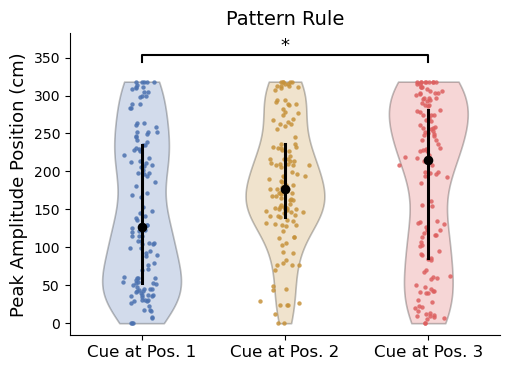

In [97]:
df_peak_pattern, peak_mat_pattern = get_rule_envelope_peaks(
    data=data,
    params=params,
    rule="pattern",
    mask=mask,
    ana_bt=("correct",),
)

fig, ax, stat_pattern = plot_rule_peak_violin(
    peak_mat=peak_mat_pattern,
    rule="pattern",
)

position_1: idx=(4, 0), env=(998, 3184), selected=(129, 3184), peak range=0.0-318.3
position_2: idx=(5, 0), env=(998, 3184), selected=(129, 3184), peak range=0.0-317.5
position_3: idx=(6, 0), env=(998, 3184), selected=(129, 3184), peak range=0.0-318.2
position: Friedman p = 0.7968, n = 129


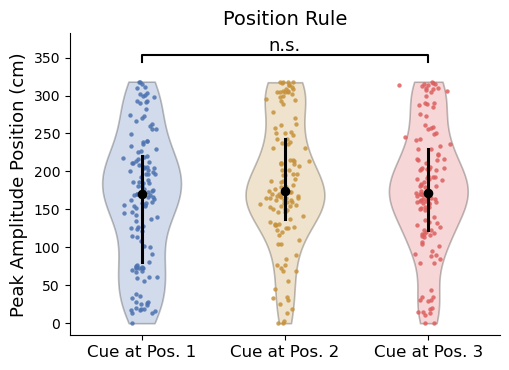

In [98]:
df_peak_position, peak_mat_position = get_rule_envelope_peaks(
    data=data,
    params=params,
    rule="position",
    mask=mask,
    ana_bt=("correct",),
)

fig, ax, stat_position = plot_rule_peak_violin(
    peak_mat=peak_mat_position,
    rule="position",
)